# Computer Vision 1: Assignment 2

Task 1

Group Number 43

Marek Drwal

01.12.2025

## setup

In [1]:
import numpy as np
import skimage as ski
import matplotlib.pyplot as plt

In [2]:
template_pth = 'template.jpg'
panorama_pth = 'panorama.jpg'

## imgs

In [3]:
template = ski.io.imread(template_pth)
panorama = ski.io.imread(panorama_pth)

In [4]:
template = ski.color.rgb2gray(template)
panorama = ski.color.rgb2gray(panorama)

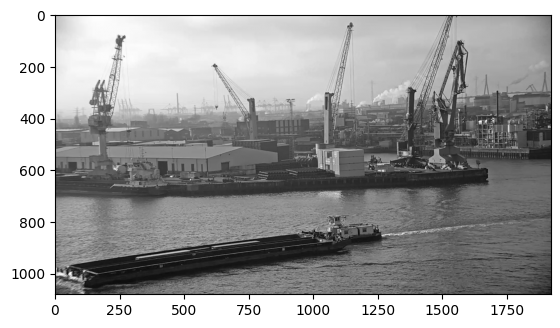

In [5]:
plt.imshow(template, cmap=plt.cm.gray)

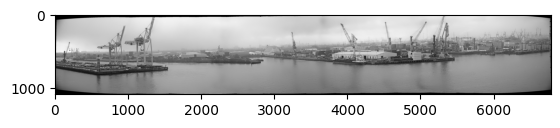

In [6]:
plt.imshow(panorama, cmap=plt.cm.gray)

## correlation

https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_template.html#sphx-glr-auto-examples-features-detection-plot-template-py

In [7]:
corr = ski.feature.match_template(template=template, image=panorama)
corr

array([[0.20999634, 0.21090948, 0.21182656, ..., 0.58245736, 0.58234454,
        0.58218039],
       [0.21480618, 0.21572695, 0.21664841, ..., 0.586774  , 0.58666093,
        0.58649801],
       [0.2196948 , 0.22062013, 0.22154336, ..., 0.59019221, 0.59008372,
        0.58993189]])

In [8]:
np.round(corr, 2)

array([[0.21, 0.21, 0.21, ..., 0.58, 0.58, 0.58],
       [0.21, 0.22, 0.22, ..., 0.59, 0.59, 0.59],
       [0.22, 0.22, 0.22, ..., 0.59, 0.59, 0.59]])

In [9]:
corr.shape

(3, 4865)

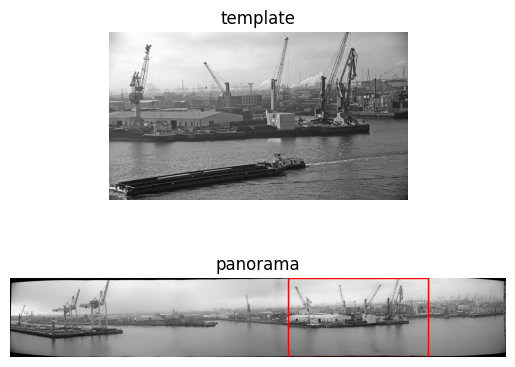

In [10]:
ij = np.unravel_index(np.argmax(corr), corr.shape)
x, y = ij[::-1]
fig = plt.figure()
ax1 = plt.subplot(2, 1, 1)
ax2 = plt.subplot(2, 1, 2)

ax1.imshow(template, cmap=plt.cm.gray)
ax1.set_axis_off()
ax1.set_title('template')

ax2.imshow(panorama, cmap=plt.cm.gray)
ax2.set_axis_off()
ax2.set_title('panorama')
# highlight matched region
hcoin, wcoin = template.shape
rect = plt.Rectangle((x, y), wcoin, hcoin, edgecolor='r', facecolor='none')
ax2.add_patch(rect)

plt.show()

## flipped template

In [11]:
template = template[:, ::-1]

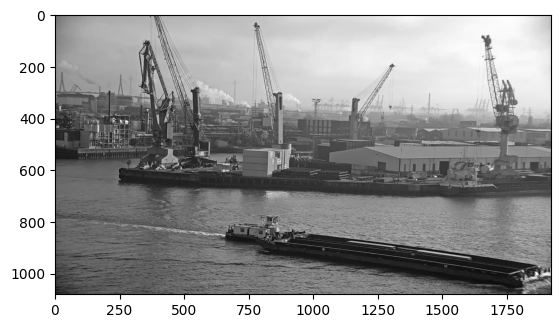

In [12]:
plt.imshow(template, cmap=plt.cm.gray)

In [13]:
corr = ski.feature.match_template(template=template, image=panorama)

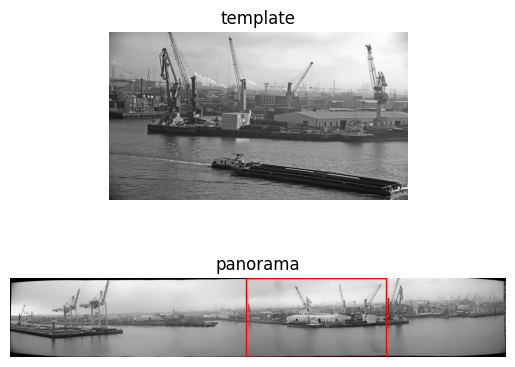

In [14]:
ij = np.unravel_index(np.argmax(corr), corr.shape)
x, y = ij[::-1]
fig = plt.figure()
ax1 = plt.subplot(2, 1, 1)
ax2 = plt.subplot(2, 1, 2)

ax1.imshow(template, cmap=plt.cm.gray)
ax1.set_axis_off()
ax1.set_title('template')

ax2.imshow(panorama, cmap=plt.cm.gray)
ax2.set_axis_off()
ax2.set_title('panorama')
# highlight matched region
hcoin, wcoin = template.shape
rect = plt.Rectangle((x, y), wcoin, hcoin, edgecolor='r', facecolor='none')
ax2.add_patch(rect)

plt.show()

not at all